In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / 'data' / 'processed_data'

# Load all cleaned data
nav         = pd.read_csv(PROCESSED_DIR / 'clean_nav.csv', parse_dates=['date'])
fund_master = pd.read_csv(PROCESSED_DIR / 'clean_fund_master.csv')
perf        = pd.read_csv(PROCESSED_DIR / 'clean_performance.csv')
aum         = pd.read_csv(PROCESSED_DIR / 'clean_aum.csv', parse_dates=['date'])
sip         = pd.read_csv(PROCESSED_DIR / 'clean_sip_inflows.csv')
txn         = pd.read_csv(PROCESSED_DIR / 'clean_transactions.csv', parse_dates=['transaction_date'])
folio       = pd.read_csv(PROCESSED_DIR / 'clean_folio_count.csv')
portfolio   = pd.read_csv(PROCESSED_DIR / 'clean_portfolio_holdings.csv')
benchmark   = pd.read_csv(PROCESSED_DIR / 'clean_benchmark_indices.csv', parse_dates=['date'])
category_inf= pd.read_csv(PROCESSED_DIR / 'clean_category_inflows.csv')

print("✅ All datasets loaded for EDA")

✅ All datasets loaded for EDA


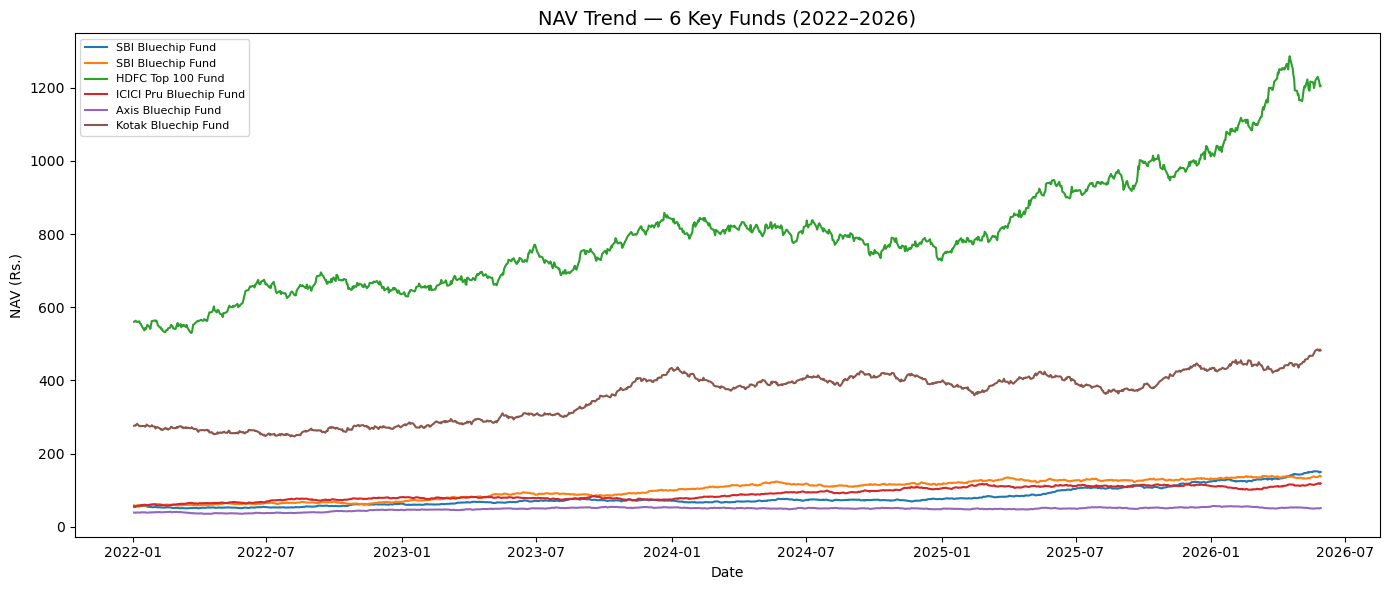

✅ Chart 1 saved


In [2]:
key_funds = [119551, 119552, 125497, 120503, 119092, 120841]
nav_filtered = nav[nav['amfi_code'].isin(key_funds)]
nav_merged = nav_filtered.merge(fund_master[['amfi_code','scheme_name']], on='amfi_code')
# Shorten names for legend
nav_merged['short_name'] = nav_merged['scheme_name'].str.extract(r'^([\w\s]+Fund)')

plt.figure(figsize=(14,6))
for code in key_funds:
    df = nav_merged[nav_merged['amfi_code'] == code]
    plt.plot(df['date'], df['nav'], label=df['short_name'].iloc[0])

plt.title('NAV Trend — 6 Key Funds (2022–2026)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('NAV (Rs.)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart1_nav_trend.png', dpi=150)
plt.show()
print("✅ Chart 1 saved")

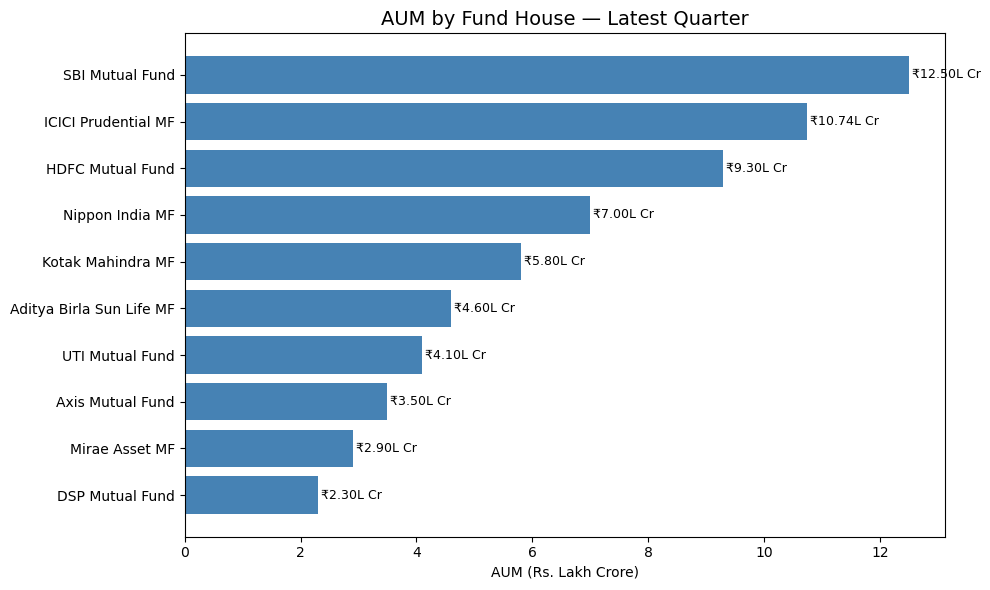

✅ Chart 2 saved


In [3]:
aum_latest = aum[aum['date'] == aum['date'].max()]
aum_sorted = aum_latest.sort_values('aum_lakh_crore', ascending=True)

plt.figure(figsize=(10,6))
bars = plt.barh(aum_sorted['fund_house'], aum_sorted['aum_lakh_crore'], color='steelblue')
plt.xlabel('AUM (Rs. Lakh Crore)')
plt.title('AUM by Fund House — Latest Quarter', fontsize=14)
for bar, val in zip(bars, aum_sorted['aum_lakh_crore']):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'₹{val:.2f}L Cr', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart2_aum_by_fundhouse.png', dpi=150)
plt.show()
print("✅ Chart 2 saved")

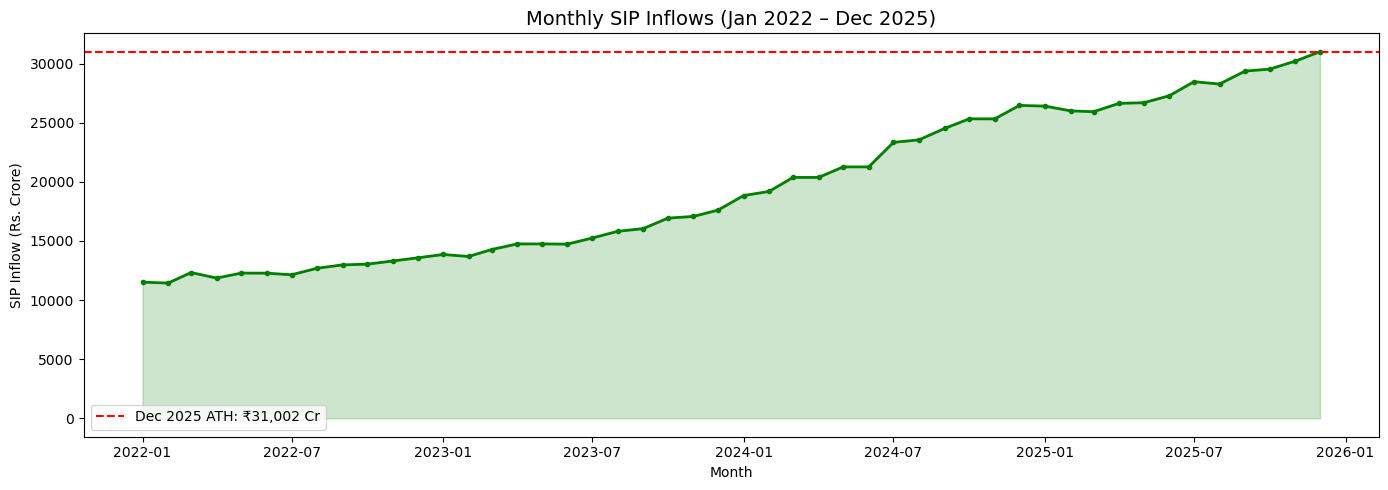

✅ Chart 3 saved


In [4]:
sip['month'] = pd.to_datetime(sip['month'])
sip_sorted = sip.sort_values('month')

plt.figure(figsize=(14,5))
plt.plot(sip_sorted['month'], sip_sorted['sip_inflow_crore'], 
         color='green', linewidth=2, marker='o', markersize=3)
plt.axhline(y=31002, color='red', linestyle='--', label='Dec 2025 ATH: ₹31,002 Cr')
plt.fill_between(sip_sorted['month'], sip_sorted['sip_inflow_crore'], alpha=0.2, color='green')
plt.title('Monthly SIP Inflows (Jan 2022 – Dec 2025)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('SIP Inflow (Rs. Crore)')
plt.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart3_sip_trend.png', dpi=150)
plt.show()
print("✅ Chart 3 saved")

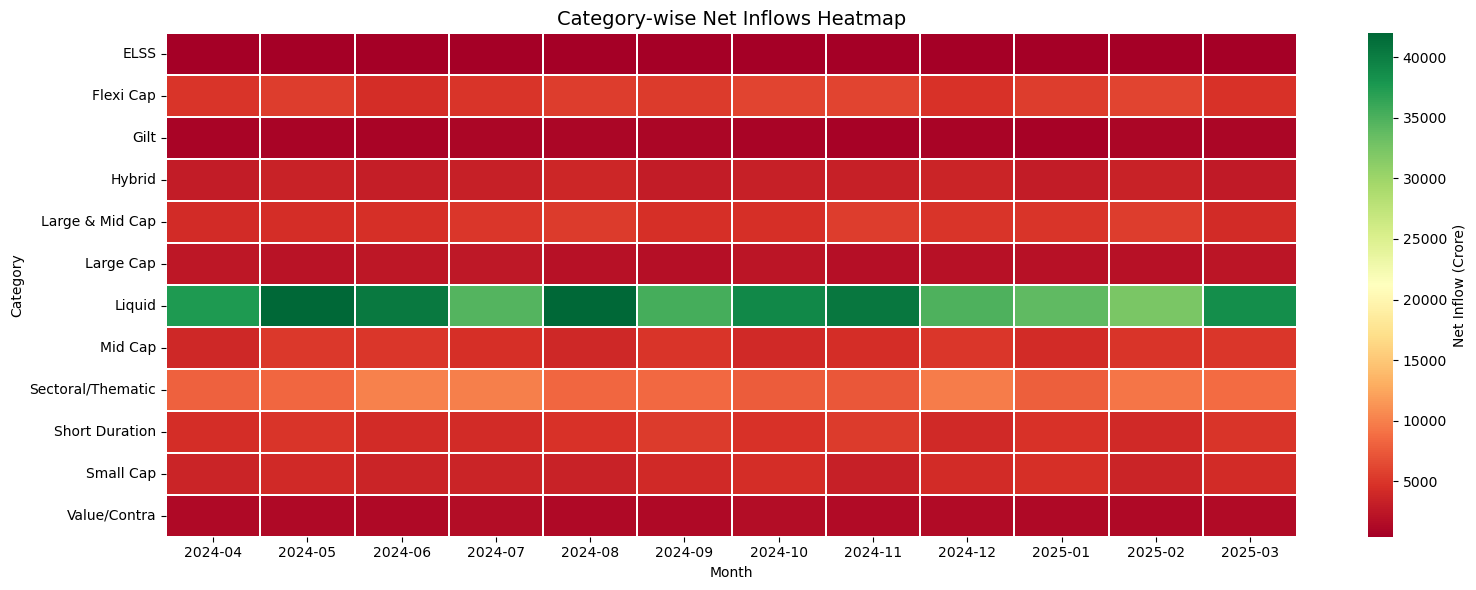

✅ Chart 4 saved


In [5]:
category_inf['month'] = pd.to_datetime(category_inf['month'])
pivot = category_inf.pivot_table(index='category', columns=category_inf['month'].dt.strftime('%Y-%m'), 
                                  values='net_inflow_crore')

plt.figure(figsize=(16,6))
sns.heatmap(pivot, cmap='RdYlGn', fmt='.0f', linewidths=0.3,
            cbar_kws={'label': 'Net Inflow (Crore)'})
plt.title('Category-wise Net Inflows Heatmap', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart4_category_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 saved")

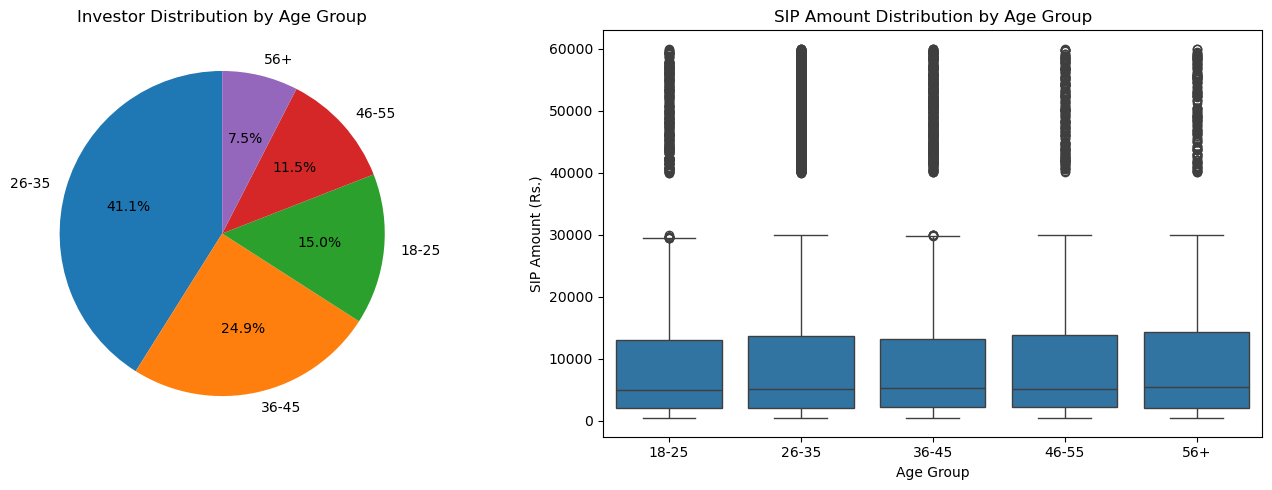

✅ Charts 5 & 6 saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Age group pie
age_counts = txn['age_group'].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Investor Distribution by Age Group')

# SIP amount by age group boxplot
sip_txn = txn[txn['transaction_type'].str.upper() == 'SIP']
sns.boxplot(data=sip_txn, x='age_group', y='amount_inr', ax=axes[1],
            order=['18-25','26-35','36-45','46-55','56+'])
axes[1].set_title('SIP Amount Distribution by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('SIP Amount (Rs.)')

plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart5_demographics.png', dpi=150)
plt.show()
print("✅ Charts 5 & 6 saved")

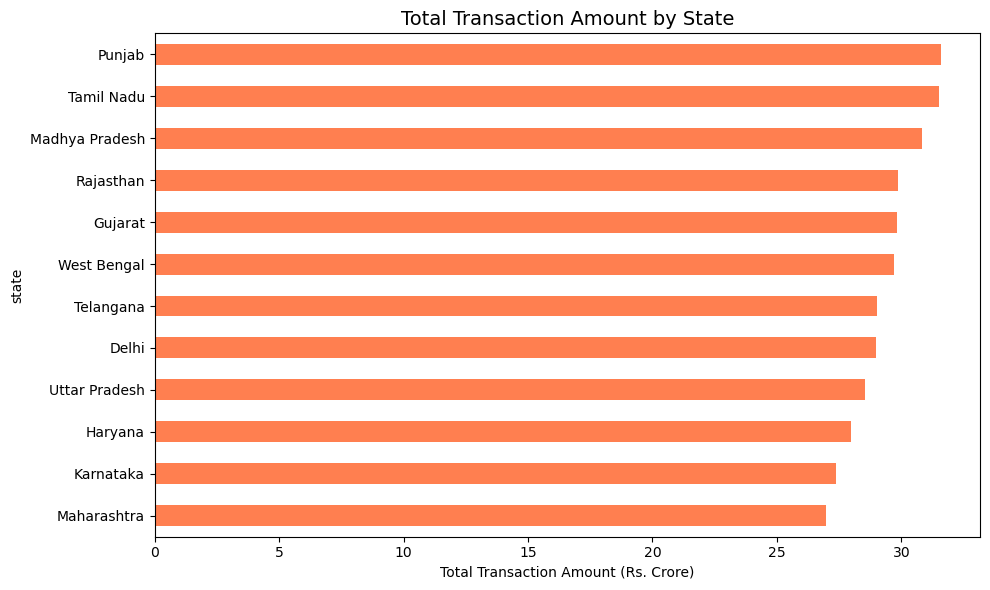

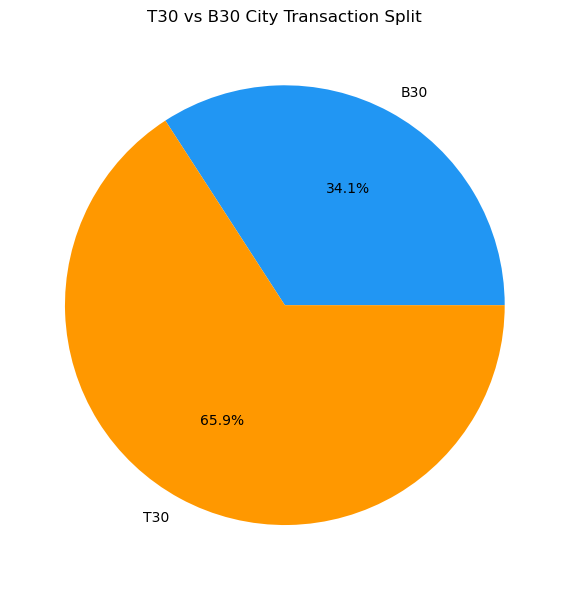

✅ Charts 6 & 7 saved


In [7]:
state_txn = txn.groupby('state')['amount_inr'].sum().sort_values() / 10000000

plt.figure(figsize=(10,6))
state_txn.plot(kind='barh', color='coral')
plt.xlabel('Total Transaction Amount (Rs. Crore)')
plt.title('Total Transaction Amount by State', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart6_state_transactions.png', dpi=150)
plt.show()

# T30 vs B30 pie
tier_split = txn.groupby('city_tier')['amount_inr'].sum()
plt.figure(figsize=(6,6))
plt.pie(tier_split, labels=tier_split.index, autopct='%1.1f%%', colors=['#2196F3','#FF9800'])
plt.title('T30 vs B30 City Transaction Split')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart7_t30_b30.png', dpi=150)
plt.show()
print("✅ Charts 6 & 7 saved")

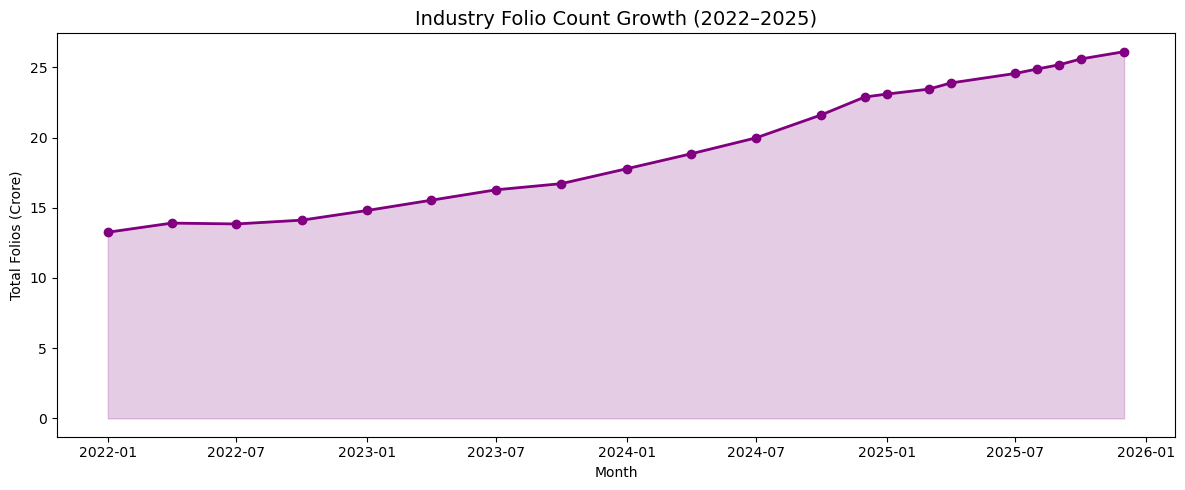

✅ Chart 8 saved


In [8]:
folio['month'] = pd.to_datetime(folio['month'])
folio_sorted = folio.sort_values('month')

plt.figure(figsize=(12,5))
plt.plot(folio_sorted['month'], folio_sorted['total_folios_crore'],
         marker='o', color='purple', linewidth=2)
plt.fill_between(folio_sorted['month'], folio_sorted['total_folios_crore'], alpha=0.2, color='purple')
plt.title('Industry Folio Count Growth (2022–2025)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Folios (Crore)')
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart8_folio_growth.png', dpi=150)
plt.show()
print("✅ Chart 8 saved")

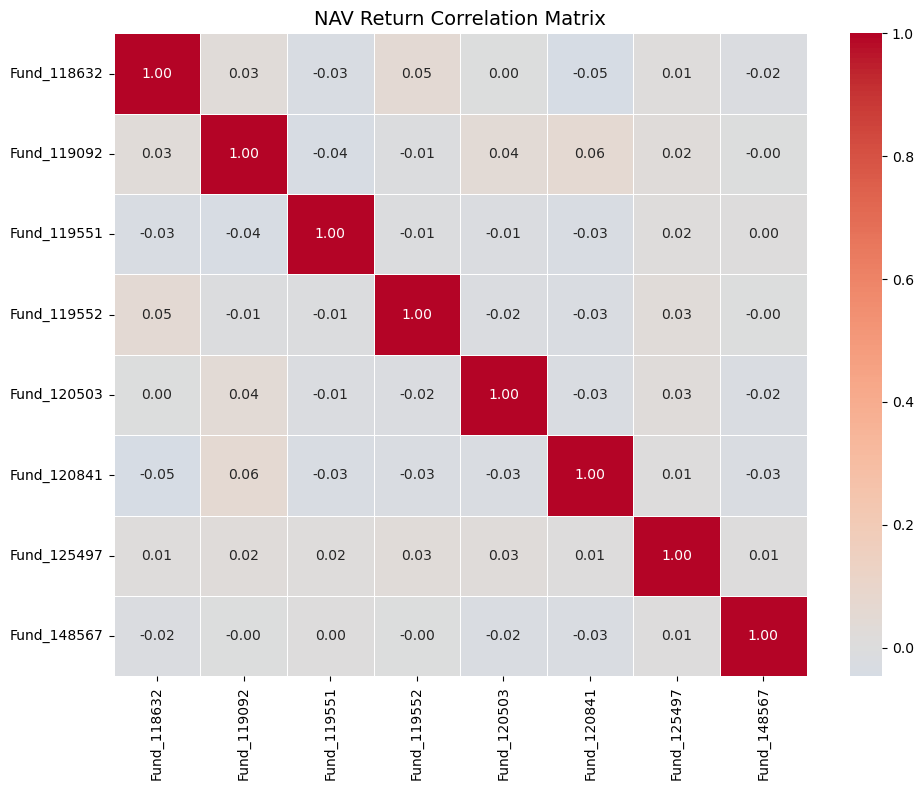

✅ Chart 9 saved


In [9]:
# Pick 8 funds for correlation
selected = [119551, 119552, 125497, 120503, 119092, 120841, 118632, 148567]
nav_sel = nav[nav['amfi_code'].isin(selected)][['date','amfi_code','daily_return_pct']]
nav_pivot = nav_sel.pivot_table(index='date', columns='amfi_code', values='daily_return_pct')
nav_pivot.columns = [f"Fund_{c}" for c in nav_pivot.columns]

plt.figure(figsize=(10,8))
sns.heatmap(nav_pivot.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('NAV Return Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart9_correlation.png', dpi=150)
plt.show()
print("✅ Chart 9 saved")

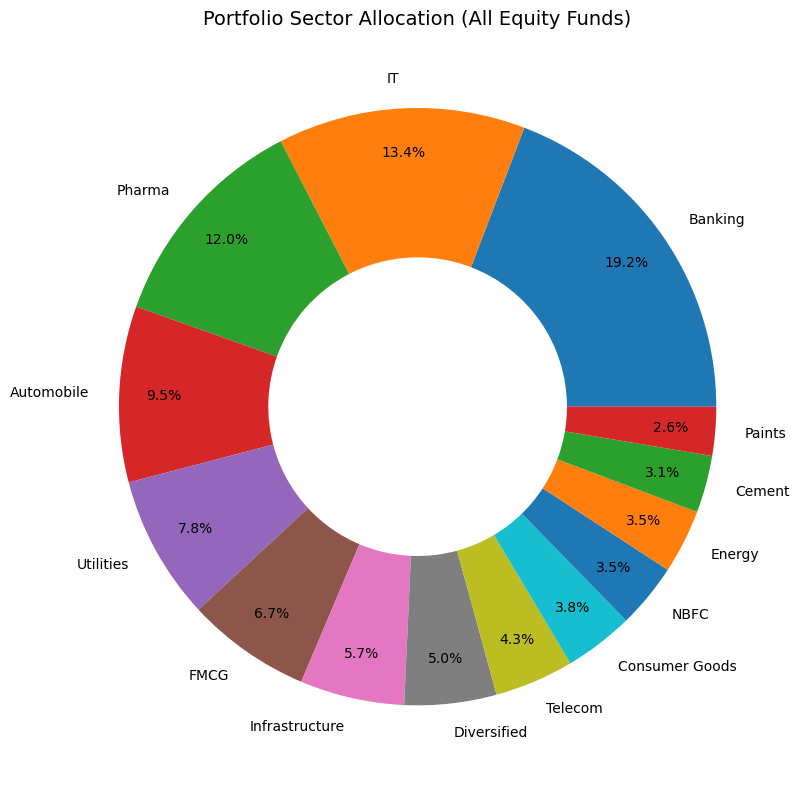

✅ Chart 10 saved


In [10]:
sector_weights = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,8))
wedges, texts, autotexts = plt.pie(sector_weights, labels=sector_weights.index,
                                    autopct='%1.1f%%', pctdistance=0.85,
                                    wedgeprops=dict(width=0.5))
plt.title('Portfolio Sector Allocation (All Equity Funds)', fontsize=14)
plt.tight_layout()
plt.savefig(BASE_DIR / 'reports' / 'chart10_sector_allocation.png', dpi=150)
plt.show()
print("✅ Chart 10 saved")

In [11]:
findings = """
## 📋 Key EDA Findings

1. **NAV Growth**: All 6 tracked funds showed strong growth from 2022–2026, 
   with a notable dip in early 2022 and strong rally from 2023 onwards.

2. **AUM Dominance**: SBI Mutual Fund leads with the highest AUM, 
   followed by ICICI Prudential and HDFC Mutual Fund.

3. **SIP Growth**: Monthly SIP inflows grew consistently from ₹11,517 Cr 
   (Jan 2022) to an all-time high of ₹31,002 Cr (Dec 2025) — a 169% increase.

4. **Category Trends**: Large Cap and Mid Cap funds dominate net inflows, 
   with Small Cap seeing increased interest in 2024-25.

5. **Investor Demographics**: 26-35 age group has the highest number of 
   SIP transactions, but 56+ investors have the highest average SIP amount.

6. **Geography**: Punjab and Tamil Nadu lead in total transaction amounts. 
   T30 cities contribute ~60% of total investment volume.

7. **Folio Growth**: Industry folios grew from 13.26 crore (Jan 2022) to 
   26.12 crore (Dec 2025) — nearly doubled in 4 years.

8. **Correlation**: Direct and Regular plans of the same fund show near-perfect 
   correlation (>0.99), while funds across categories show moderate correlation.

9. **Sector Concentration**: Banking and IT dominate equity fund portfolios, 
   together accounting for over 40% of total holdings.

10. **Benchmark**: NIFTY Midcap 150 delivered the highest returns (267%) 
    among all tracked indices from 2022–2026.
"""
print(findings)


## 📋 Key EDA Findings

1. **NAV Growth**: All 6 tracked funds showed strong growth from 2022–2026, 
   with a notable dip in early 2022 and strong rally from 2023 onwards.

2. **AUM Dominance**: SBI Mutual Fund leads with the highest AUM, 
   followed by ICICI Prudential and HDFC Mutual Fund.

3. **SIP Growth**: Monthly SIP inflows grew consistently from ₹11,517 Cr 
   (Jan 2022) to an all-time high of ₹31,002 Cr (Dec 2025) — a 169% increase.

4. **Category Trends**: Large Cap and Mid Cap funds dominate net inflows, 
   with Small Cap seeing increased interest in 2024-25.

5. **Investor Demographics**: 26-35 age group has the highest number of 
   SIP transactions, but 56+ investors have the highest average SIP amount.

6. **Geography**: Punjab and Tamil Nadu lead in total transaction amounts. 
   T30 cities contribute ~60% of total investment volume.

7. **Folio Growth**: Industry folios grew from 13.26 crore (Jan 2022) to 
   26.12 crore (Dec 2025) — nearly doubled in 4 years.

8. *